# 05 · One-to-Many — Generating Sequences with an Autoregressive RNN

So far our RNNs **consumed** sequences and produced a single answer (many-to-one). Now we flip the
arrow: from a small seed we **produce a whole sequence**, one element at a time. This is the
**one-to-many / generative** pattern behind text generation, music generation, and — the modern
descendant — the language models you use every day (which are Transformers, but share this exact
*autoregressive* generation idea).

We'll build a **character-level name generator**: train an LSTM on a list of real names, then let
it invent **new, plausible-sounding names**. It's small, fast, and the results are fun and easy to
judge by eye.

You'll learn:
1. How to turn text into integer tokens with a **vocabulary**.
2. The subtle but crucial point: we **train** the model as *many-to-many* (predict the next
   character at every position), but we **use** it as *one-to-many* (feed its own output back in).
3. **Embeddings** — a learned lookup table that replaces clumsy one-hot vectors.
4. **Sampling** and the **temperature** knob that controls creativity vs. safety.

In [122]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. The data: a list of names

We embed a corpus of names directly so the notebook is fully self-contained (no downloads). The
model will learn the *statistics of letter sequences* in these names — which letters tend to
start a name, common endings like "-ia" or "-on", plausible consonant/vowel patterns — and use
that to generate new ones.

In [123]:
names = [
    "amelia","oliver","sophia","liam","emma","noah","ava","william","isabella","james",
    "mia","benjamin","charlotte","lucas","amara","henry","evelyn","alexander","harper","daniel",
    "elena","gabriel","aurora","samuel","luna","david","chloe","joseph","layla","matthew",
    "penelope","julian","nora","leo","hazel","adrian","violet","aaron","stella","nathan",
    "maria","antonio","lucia","marco","sofia","diego","valentina","mateo","camila","sebastian",
    "isabel","andres","carmen","pablo","elsa","victor","adriana","emilio","natalia","hugo",
    "olivia","ethan","abigail","jacob","emily","michael","elizabeth","daniel","grace","logan",
    "clara","ivan","laura","oscar","paula","ruben","teresa","alvaro","irene","javier",
    "rosa","felix","alba","bruno","noa","alma","dario","vera","enzo","nadia",
    "ana","luis","marta","jorge","sara","raul","elisa","cesar","julia","angel",
]
names = sorted(set(names))
print(f"{len(names)} names, e.g.:", names[:8])

# --- build the vocabulary (character <-> integer) ---
# We add two SPECIAL tokens:  '.' marks the END of a name (so the model learns when to stop),
# and it doubles as the START token we feed to kick off generation.
chars = ["."] + sorted(set("".join(names)))
stoi = {c: i for i, c in enumerate(chars)}   # string -> index
itos = {i: c for c, i in stoi.items()}       # index  -> string
VOCAB = len(chars)
print("vocabulary size:", VOCAB)
print("char->index map:", stoi)

99 names, e.g.: ['aaron', 'abigail', 'adrian', 'adriana', 'alba', 'alexander', 'alma', 'alvaro']
vocabulary size: 25
char->index map: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'v': 20, 'w': 21, 'x': 22, 'y': 23, 'z': 24}


## 2. Turning names into training pairs

Key idea — **next-character prediction.** For the name `ana`, we frame it as: given what we've
seen so far, predict the next character. We wrap each name with the special `.` token at both ends:

```
input :  .  a  n  a
target:  a  n  a  .
```

So at every position the target is simply the **input shifted left by one**. Training the model to
predict the next character at *every* position is a **many-to-many (aligned)** setup — and it's
far more efficient than predicting only the final character, because every position contributes a
learning signal.

In [ ]:
def encode_name(name):
    '''Return (input_ids, target_ids) for one name, using '.' as start & end marker.'''
    tokens = [stoi["."]] + [stoi[c] for c in name] + [stoi["."]]
    x = tokens[:-1]     # everything except the last  -> inputs
    y = tokens[1:]      # everything except the first -> targets (shifted by one)
    return x, y

xi, yi = encode_name("ana")
print("name 'ana' becomes:")
print("  input tokens :", xi, "->", [itos[i] for i in xi])
print("  target tokens:", yi, "->", [itos[i] for i in yi])
print("\nAt each step the model must predict the NEXT character (the target).")

# Because names have different lengths, we PAD each sequence to the longest, and remember the
# real length so padding doesn't pollute the loss.
encoded = [encode_name(n) for n in names]
maxlen = max(len(x) for x, _ in encoded)

X = torch.full((len(names), maxlen), stoi["."], dtype=torch.long)
Y = torch.full((len(names), maxlen), stoi["."], dtype=torch.long)

# IMPORTANT: dont scale the inputs, they are just integer indices (0..VOCAB-1) that will be fed to an embedding layer.
lengths = []
for i, (x, y) in enumerate(encoded):
    X[i, :len(x)] = torch.tensor(x)
    Y[i, :len(y)] = torch.tensor(y)
    lengths.append(len(x))
lengths = torch.tensor(lengths)
print("\nX shape (names, maxlen):", tuple(X.shape))

name 'ana' becomes:
  input tokens : [0, 1, 13, 1] -> ['.', 'a', 'n', 'a']
  target tokens: [1, 13, 1, 0] -> ['a', 'n', 'a', '.']

At each step the model must predict the NEXT character (the target).

X shape (names, maxlen): (99, 10)


## 🎯 Key concept · Many-to-many *training* vs one-to-many *generation*

This notebook does something that confuses almost everyone the first time: it **trains** the model
one way (**many-to-many**) but **uses** it a completely different way (**one-to-many**). Let's make
that crystal clear *before* the code, because understanding it *is* the point of this notebook.

**The puzzle.** In Section 2 we turned each name into a *shifted* pair — e.g. for `ana`:

```
input :  .  a  n  a
target:  a  n  a  .
```

At **training** time the model sees the **whole name at once** and, at **every position**, predicts
the **next** character. That is **many-to-many**: N inputs → N outputs, one target per step.

At **generation** time we have **no name to feed in** — we are trying to *invent* one! We only have
a start token `.`, so we must produce characters **one at a time**, feeding each new character back
in to get the next. That is **one-to-many**: 1 seed → many outputs.


So the *same weights* are used in two different "wirings". These can be done since as explained in
notebook 02, section 5. An RNNs don't have a fixed sequence length input. They are able to work
with difference sequence length.

The next two diagrams show each wiring; then we explain the crucial reason they **must** differ.

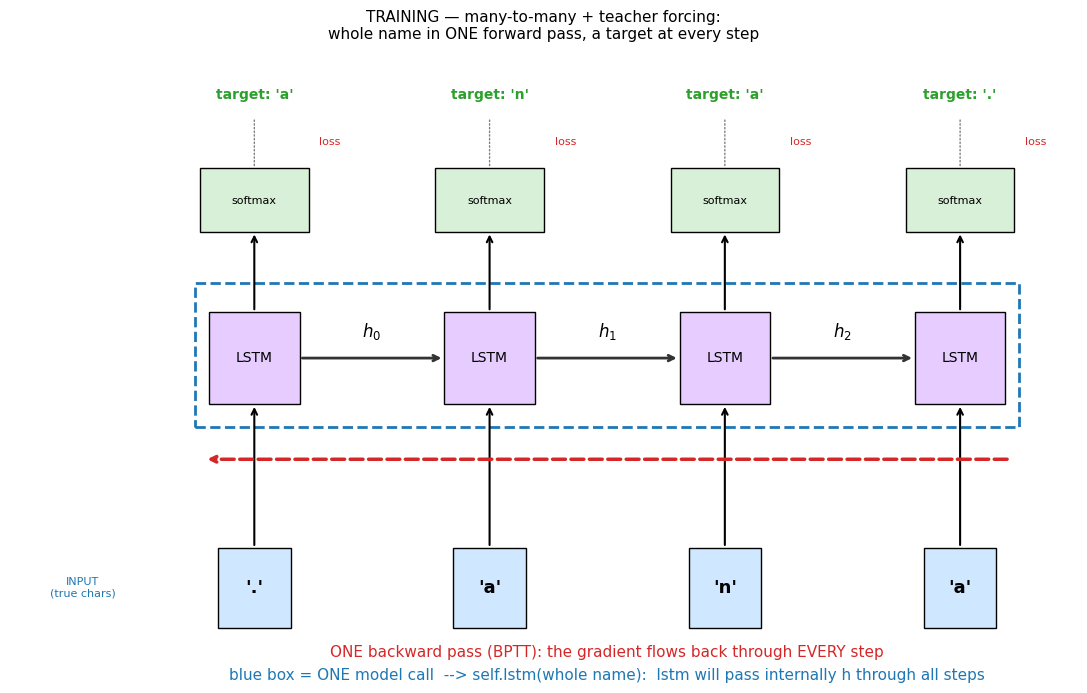

In [125]:
# Diagram: how TRAINING works — many-to-many with "teacher forcing".
from matplotlib.patches import Rectangle
BLUE = "#1f77b4"

def draw_training():
    inp = [".", "a", "n", "a"]      # the TRUE input chars (teacher forcing)
    tgt = ["a", "n", "a", "."]      # target = the next char, at every position
    n, xs = 4, 2.6
    y_in, y_cell, y_pred = 0.25, 2.2, 3.7
    fig, ax = plt.subplots(figsize=(11, 7))
    # ONE blue dashed box around ALL cells = a single self.lstm(sequence) call
    xL, xR = 1 - 0.65, (n - 1) * xs + 1 + 0.65
    ax.add_patch(Rectangle((xL, 2.0), xR - xL, 1.25, fill=False, ec=BLUE, ls="--", lw=2))
    for t in range(n):
        x = t * xs + 1
        ax.add_patch(Rectangle((x - 0.4, y_in), 0.8, 0.7, color="#cfe8ff", ec="black"))
        ax.text(x, y_in + 0.35, f"'{inp[t]}'", ha="center", va="center", fontsize=13, weight="bold")
        ax.add_patch(Rectangle((x - 0.5, y_cell), 1.0, 0.8, color="#e6ccff", ec="black"))
        ax.text(x, y_cell + 0.4, "LSTM", ha="center", va="center", fontsize=10)
        ax.annotate("", xy=(x, y_cell), xytext=(x, y_in + 0.7), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.annotate("", xy=(x, y_pred), xytext=(x, y_cell + 0.8), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.add_patch(Rectangle((x - 0.6, y_pred), 1.2, 0.55, color="#d7f0d7", ec="black"))
        ax.text(x, y_pred + 0.27, "softmax", ha="center", va="center", fontsize=8)
        ax.text(x, y_pred + 1.15, f"target: '{tgt[t]}'", ha="center", fontsize=10, color="#2ca02c", weight="bold")
        ax.annotate("", xy=(x, y_pred + 1.0), xytext=(x, y_pred + 0.55),
                    arrowprops=dict(arrowstyle="-", lw=1, ls=":", color="gray"))
        ax.text(x + 0.72, y_pred + 0.75, "loss", ha="left", fontsize=8, color="#d62728")
        if t < n - 1:                                   # hidden state h_t passed to the next step
            ax.annotate("", xy=(x + xs - 0.5, y_cell + 0.4), xytext=(x + 0.5, y_cell + 0.4),
                        arrowprops=dict(arrowstyle="->", lw=2, color="#333"))
            ax.text(x + xs / 2, y_cell + 0.58, f"$h_{t}$", ha="center", fontsize=12)
    ax.annotate("", xy=(xL + 0.1, 1.72), xytext=(xR - 0.1, 1.72),
                arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#d62728", ls="--"))
    ax.text((xL + xR) / 2, 0, "ONE backward pass (BPTT): the gradient flows back through EVERY step",
            ha="center", color="#d62728", fontsize=11)
    ax.text((xL + xR) / 2, -0.2,
            "blue box = ONE model call  --> self.lstm(whole name):  lstm will pass internally h through all steps",
            ha="center", color=BLUE, fontsize=11)
    ax.text(-0.9, y_in + 0.35, "INPUT\n(true chars)", ha="center", va="center", fontsize=8, color=BLUE)
    ax.set_xlim(-1.7, (n - 1) * xs + 2.3); ax.set_ylim(0.05, 5.3); ax.axis("off")
    ax.set_title("TRAINING — many-to-many + teacher forcing:\nwhole name in ONE forward pass, a target at every step", fontsize=11)
    plt.tight_layout(); plt.show()

draw_training()

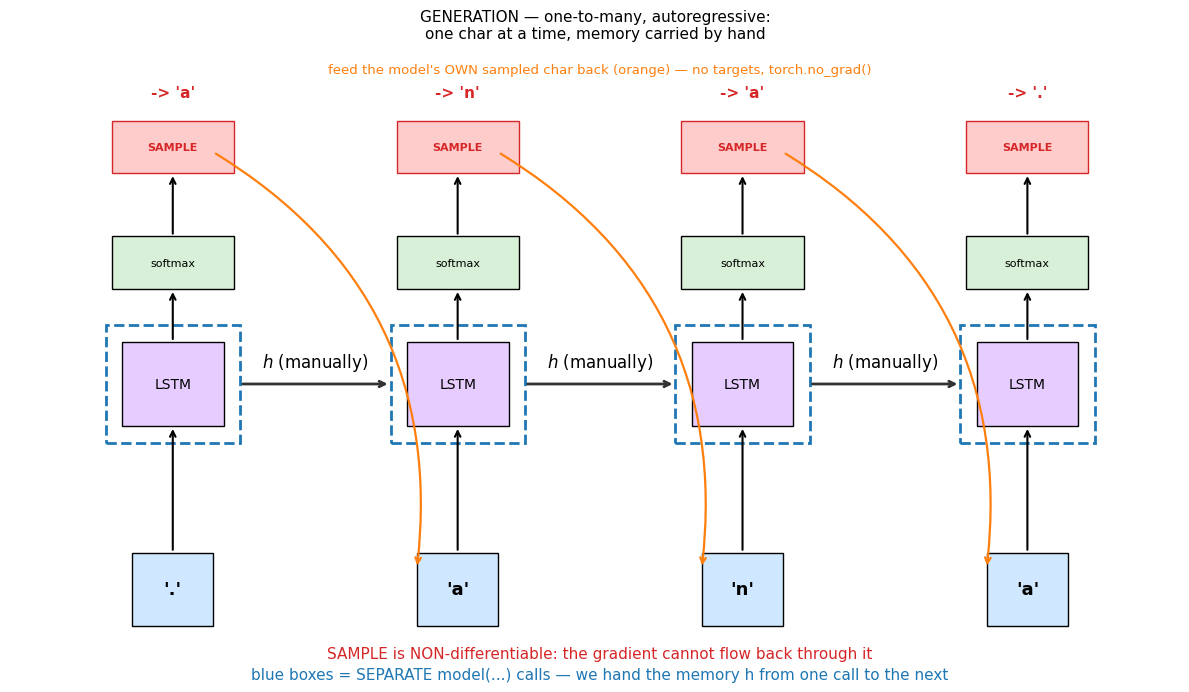

In [126]:
# Diagram: how GENERATION works — one-to-many, autoregressive.
from matplotlib.patches import Rectangle
BLUE = "#1f77b4"

def draw_generation():
    seq = [".", "a", "n", "a"]     # start token, then previously-SAMPLED chars fed back in
    gen = ["a", "n", "a", "."]     # what the model samples at each step
    n, xs = 4, 2.8
    y_in, y_cell, y_soft, y_samp = 0.3, 2.2, 3.5, 4.6
    fig, ax = plt.subplots(figsize=(12, 7))
    for t in range(n):
        x = t * xs + 1
        # each LSTM is its OWN model(...) call -> its own blue dashed box
        ax.add_patch(Rectangle((x - 0.66, y_cell - 0.16), 1.32, 1.12, fill=False, ec=BLUE, ls="--", lw=2))
        ax.add_patch(Rectangle((x - 0.4, y_in), 0.8, 0.7, color="#cfe8ff", ec="black"))
        ax.text(x, y_in + 0.35, f"'{seq[t]}'", ha="center", va="center", fontsize=13, weight="bold")
        ax.annotate("", xy=(x, y_cell), xytext=(x, y_in + 0.7), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.add_patch(Rectangle((x - 0.5, y_cell), 1.0, 0.8, color="#e6ccff", ec="black"))
        ax.text(x, y_cell + 0.4, "LSTM", ha="center", va="center", fontsize=10)
        ax.annotate("", xy=(x, y_soft), xytext=(x, y_cell + 0.8), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.add_patch(Rectangle((x - 0.6, y_soft), 1.2, 0.5, color="#d7f0d7", ec="black"))
        ax.text(x, y_soft + 0.25, "softmax", ha="center", va="center", fontsize=8)
        ax.add_patch(Rectangle((x - 0.6, y_samp), 1.2, 0.5, color="#ffcccc", ec="#d62728"))
        ax.text(x, y_samp + 0.25, "SAMPLE", ha="center", va="center", fontsize=8, color="#d62728", weight="bold")
        ax.annotate("", xy=(x, y_samp), xytext=(x, y_soft + 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
        ax.text(x, y_samp + 0.72, f"-> '{gen[t]}'", ha="center", fontsize=11, weight="bold", color="#d62728")
        if t < n - 1:
            ax.annotate("", xy=(x + xs - 0.4, y_in + 0.55), xytext=(x + 0.4, y_samp + 0.2),  # feed sample back
                        arrowprops=dict(arrowstyle="->", lw=1.6, color="#ff7f0e",
                                        connectionstyle="arc3,rad=-0.32"))
            ax.annotate("", xy=(x + xs - 0.66, y_cell + 0.4), xytext=(x + 0.66, y_cell + 0.4),  # h passed by hand
                        arrowprops=dict(arrowstyle="->", lw=2, color="#333"))
            ax.text(x + xs / 2, y_cell + 0.56, f"$h$ (manually)", ha="center", fontsize=12)
    ax.text((n - 1) * xs / 2 + 1, 5.55,
            "feed the model's OWN sampled char back (orange) — no targets, torch.no_grad()",
            ha="center", fontsize=9.5, color="#ff7f0e")
    ax.text((n - 1) * xs / 2 + 1, 0,
            "SAMPLE is NON-differentiable: the gradient cannot flow back through it",
            ha="center", color="#d62728", fontsize=11)
    ax.text((n - 1) * xs / 2 + 1, -0.2,
            "blue boxes = SEPARATE model(...) calls — we hand the memory h from one call to the next",
            ha="center", color=BLUE, fontsize=11)
    ax.set_xlim(-0.6, (n - 1) * xs + 2.5); ax.set_ylim(0.05, 5.8); ax.axis("off")
    ax.set_title("GENERATION — one-to-many, autoregressive:\none char at a time, memory carried by hand", fontsize=11)
    plt.tight_layout(); plt.show()

draw_generation()

### Why we *train* many-to-many but *generate* one-to-many

Why not train the model the same way we use it — generate one character, feed it back, generate the
next? Two decisive reasons:

**1. Sampling cuts the gradient (the big one).** To generate, we must turn the softmax
*probabilities* into an actual *character* — we **sample** (or take the `argmax`). Picking a discrete
symbol is a **non-differentiable** operation: there is no smooth slope from the chosen character back
to the probabilities, so **gradients cannot flow through a `SAMPLE` step**. If training were built on
sampled characters, back-propagation would hit each red `SAMPLE` box and **stop dead** — the network
beneath it would get no learning signal. Training would be crippled.

**Teacher forcing** sidesteps this completely: during training we feed the model the **true next
character** (from the real name), *not* a sampled one. No sampling appears in the training loop, so
the computation graph stays **fully differentiable from the last step all the way back to the
first**, and Back-Propagation Through Time (BPTT) updates every weight. (That's the red dashed arrow
in the training diagram — one backward pass reaches every step.)

**2. A target at every position, in parallel.** Feeding the whole true name at once gives a *correct
answer* at each of the N positions, so we get N learning signals from a single forward/backward pass
— fast and stable. Generating step-by-step gives no ground truth to compare against (we're *inventing*
the name), and early mistakes would compound during training.

### What actually changes between the two modes — the **memory**

The model is *identical*; what changes is **who supplies each step's input and hidden state**:

| | **Training (many-to-many)** | **Generation (one-to-many)** |
|---|---|---|
| input at step *t* | the **true** char (teacher forcing) | the model's **own** previous sample |
| how long | the **whole name at once** (one `self.lstm(seq)` call) | **one char per call**, in a Python loop |
| hidden state `h` | PyTorch threads it **internally** across the sequence | **we** capture `h` and hand it back **ourselves** |
| targets / loss | yes — one per step | none — we're generating |
| gradient | flows through all steps (BPTT) | none — wrapped in `torch.no_grad()` |

That last row is the key: in **generation** you'll literally see us keep the memory by hand —
`logits, hidden = model(idx, hidden)` — capturing `hidden` and passing it into the *next* call. In
**training** we never do that manually, because a single `self.lstm(embeddings)` call over the whole
name lets PyTorch thread the hidden state through every step **and** keep the graph intact so BPTT
can flow all the way back.

> 🔑 **One-line summary:** train with **teacher forcing** (true chars, whole sequence, gradient flows
> everywhere); generate **autoregressively** (own samples, one step at a time, memory passed by hand,
> no gradient). We *can't* train the autoregressive way because **sampling is non-differentiable and
> would cut the gradient.**

Keep these two pictures in mind as you read **Section 4 (training)** and **Section 5 (generation)**.

## 3. Embeddings: a better way to feed characters

A character is a *category*, not a number — "c" (index 3) isn't "three times" the start token.
Two ways to feed categories to a network:

- **One-hot vectors** — a length-`VOCAB` vector of zeros with a single 1. Wasteful and carries no
  notion of similarity between characters.
- **Embeddings** *(what we use)* — a small **learned lookup table** mapping each character id to a
  dense vector (say 16 numbers). During training the model arranges this table so that characters
  used in similar contexts end up with similar vectors. `nn.Embedding` does exactly this.

Embeddings are the standard first layer for *any* categorical/token input — words, product ids,
user ids — so this pattern generalizes far beyond names.

In [127]:
# Check how the outputs of an LSTM work, and how the last output relates to the last hidden state.
# Random example
lstm = nn.LSTM(input_size=16, hidden_size=128, batch_first=True)
embed = nn.Embedding(num_embeddings=VOCAB, embedding_dim=16)
batch_size, seq_length = 4, 10
x = torch.randint(0, VOCAB, (batch_size, seq_length))  # example input
embed_out = embed(x)
h_out, (h_last, c_last) = lstm(embed_out, None)  # assuming no initial hidden state
# check if last h_out and h_last are the same or very close (they should be) with torch.allclose
print(torch.allclose(h_out[:, -1, :], h_last[0]))  # should be True

True


In [128]:
class CharGenerator(nn.Module):
    def __init__(self, vocab, embed_dim=16, hidden=128, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim)      # id -> dense vector (learned)
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=n_layers, batch_first=True)
        self.head  = nn.Linear(hidden, vocab)            # hidden -> score for each next char

    def forward(self, x, hidden=None):
        # x: (batch, time/seq_length) integer token ids
        # during training seq_length = name_length
        # during generation seq_length = 1 (we feed one char at a time)
        embed = self.embed(x)                                  # embed shape: (batch, time, embed_dim)
        h_out, (h_last, c_last) = self.lstm(embed, hidden)               # h_out shape: (batch, time, hidden)
        hidden = (h_last, c_last)
        # instead of  as in the previous notebooks h_out[:, -1, :], we must use the whole sequence (h_out), 
        # because we want a prediction at EVERY STEP, not just the last one.
        logits = self.head(h_out)  # logits shape: (batch, time, vocab)
        return logits, hidden 

model = CharGenerator(VOCAB).to(device)
print(model)
print("\nparameters:", sum(p.numel() for p in model.parameters()))

CharGenerator(
  (embed): Embedding(25, 16)
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True)
  (head): Linear(in_features=128, out_features=25, bias=True)
)

parameters: 210473


## 4. Train the generator

The loss is **cross-entropy** between the predicted next-character distribution and the true next
character, **summed over every position** of every name. We use a mask so the padding positions
don't count. This is quick — a couple hundred passes over ~90 names.

epoch  80 | loss 0.945
epoch 160 | loss 0.721
epoch 240 | loss 0.717
epoch 320 | loss 0.716
epoch 400 | loss 0.715


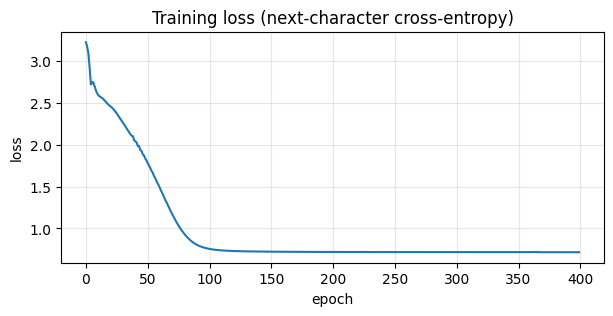

In [129]:
X, Y, lengths = X.to(device), Y.to(device), lengths.to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

# build a mask that is True for REAL positions and False for padding
mask = torch.arange(maxlen, device=device)[None, :] < lengths[:, None]   # (names, maxlen)

def masked_loss(logits, Y, mask):
    # cross-entropy expects (N*maxlen, VOCAB) vs (N*maxlen,)
    # lp means "loss per position" (per character)
    lp = F.cross_entropy(logits.reshape(-1, VOCAB), Y.reshape(-1),
                         reduction="none").reshape(Y.shape)
    # for example if the name is "ana.", the mask wil be [True, True, True, True, False, False, ...] 
    # and the loss will be averaged only over the first 4 positions.
    return (lp * mask).sum() / mask.sum()              # average over REAL positions only

losses = []
EPOCHS = 400
for epoch in range(EPOCHS):
    model.train()
    opt.zero_grad()
    logits, _ = model(X)                                   # (N, maxlen, VOCAB)
    loss = masked_loss(logits, Y, mask)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (epoch + 1) % 80 == 0:
        print(f"epoch {epoch+1:3d} | loss {loss.item():.3f}")

plt.figure(figsize=(7, 3))
plt.plot(losses); plt.title("Training loss (next-character cross-entropy)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(alpha=0.3); plt.show()

## 5. Generation = feed the model its own output (autoregression)

Here's the **one-to-many** part. To generate a name:

1. Start with the seed token `.` and an empty memory.
2. The model outputs a probability distribution over the next character.
3. **Sample** a character from that distribution.
4. **Feed that character back in** as the next input, keeping the hidden state.
5. Repeat until the model emits the end token `.`.

Because each new input is the model's *own previous output*, one seed unrolls into a whole
sequence — that feedback is exactly what "autoregressive" means.

### The temperature knob

Instead of always taking the single most-likely character (which produces repetitive, boring
output), we **sample**. **Temperature** `τ` reshapes the distribution before sampling:

- `τ → 0`: nearly always pick the top choice → *safe, repetitive, conservative.*
- `τ = 1`: sample from the model's raw probabilities → *balanced.*
- `τ > 1`: flatten the distribution → *more random, creative, but more typos.*

This single knob is the same "creativity/temperature" setting exposed by modern LLM APIs.

In [130]:
max_len = 20
temperature = 1
model.eval()
idx = torch.tensor([[stoi["."]]], device=device)   # start with the '.' token, shape (1,1)
hidden = None
out_chars = []
print("initial idx:", idx)

for _ in range(max_len):
    logits, hidden = model(idx, hidden)            # feed ONE char, carry memory forward
    # logits[0][0] changes the dimensions from (1, 1, VOCAB) to (VOCAB,) so we can apply 
    # softmax to get probabilities for the next character
    logits_1d = logits[0][0] / temperature           # last step's scores, temperature-scaled
    probs = F.softmax(logits_1d, dim=-1)              # -> a probability distribution
    # multinomial samples from the probability distribution, giving us the index of the next character
    # without this all the generated names would be the same.
    nxt = torch.multinomial(probs, num_samples=1)  # SAMPLE (not argmax) -> variety
    if nxt.item() == stoi["."]:                    # end token -> stop
        break
    out_chars.append(itos[nxt.item()])
    idx = nxt.view(1, 1)         

"".join(out_chars)

initial idx: tensor([[0]])


'sara'

In [131]:
# The same but in a function
@torch.no_grad()
def generate(model, temperature=1.0, max_len=20):
    '''Generate one name by autoregressive sampling.'''
    model.eval()
    idx = torch.tensor([[stoi["."]]], device=device)   # start with the '.' token, shape (1,1)
    hidden = None
    out_chars = []
    for _ in range(max_len):
        logits, hidden = model(idx, hidden)            # feed ONE char, carry memory forward
        logits_1 = logits[0, -1] / temperature           # last step's scores, temperature-scaled
        probs = F.softmax(logits_1, dim=-1)              # -> a probability distribution
        nxt = torch.multinomial(probs, num_samples=1)  # SAMPLE (not argmax) -> variety
        if nxt.item() == stoi["."]:                    # end token -> stop
            break
        out_chars.append(itos[nxt.item()])
        idx = nxt.view(1, 1)                            # the sampled char becomes the next input
    return "".join(out_chars)

print("Generated names at different temperatures:\n")
for temp in [0.5, 0.8, 1.0, 1.3]:
    sample = [generate(model, temperature=temp).capitalize() for _ in range(8)]
    print(f"  temperature {temp}:  {', '.join(sample)}")

Generated names at different temperatures:

  temperature 0.5:  Andres, Amara, Angel, Lucia, Isabel, Emily, Julia, Olivia
  temperature 0.8:  Lucia, James, Andres, Isabel, Ruben, Vera, Clara, Marta
  temperature 1.0:  Ruben, Elizabeth, Julia, Harper, Lucia, Ethan, Vera, Ava
  temperature 1.3:  Henry, Raul, Sofia, Natalia, William, Oliver, Emma, Amara


Notice the trend: **low temperature** gives safe, name-like (sometimes repetitive) outputs that
lean on the most common patterns; **high temperature** gets more adventurous and occasionally
produces unpronounceable strings. Some generated names will accidentally match the training set —
that's expected with such a tiny corpus.

Let's quantify how many generated names are **new** (not in the training list) vs. memorized.

In [132]:
train_set = set(names)
generated = [generate(model, temperature=1.0) for _ in range(200)]
novel = [g for g in generated if g and g not in train_set]
print(f"Of 200 generated names, {len(novel)} are NEW (not in the training set).")
print("A sample of novel inventions:")
print("  ", ", ".join(sorted(set(g.capitalize() for g in novel))[:20]))

Of 200 generated names, 1 are NEW (not in the training set).
A sample of novel inventions:
   Abmiail


### Why there are just a few new names?

1. The training objective rewards copying, not inventing
The model is trained by maximum likelihood with teacher forcing: at every position it's pushed to assign high probability to exactly the next character of a real training name. So the loss literally optimizes the model to reproduce the training names as closely as possible. Nothing in the objective rewards novelty — if anything it pushes against it. "Generate something new" is an emergent side effect of sampling, not a goal the model was trained for.

2. The dataset is tiny (~90 names)
Char-level statistics (which letters start names, plausible vowel/consonant patterns, common endings like "-ia"/"-on") have to be learned from very few examples. With so little data:
the model learns a narrow distribution that hugs the training set, so samples often land on a training name;
it never sees enough variety to generalize to the broader space of "plausible-but-unseen" names.

3. High capacity + little data → memorization
Our CharGenerator is a 2-layer LSTM with 128 hidden units — plenty of capacity to essentially memorize ~90 short strings. A memorized model, sampled at low temperature, just regurgitates names it has seen. That's why the notebook explicitly counts how many generated names are genuinely new — a lot of them aren't.

## 6. Where this scales to

The exact machinery here — **tokens → embeddings → recurrent/attention model → next-token
distribution → sample → feed back** — is the blueprint for all modern generative text models:

- Swap **characters** for **word-pieces (subword tokens)**.
- Swap the **LSTM** for a **Transformer** (better at very long context, and parallelizable in
  training).
- Train on **billions** of tokens instead of ~90 names.

…and you have the essence of a large language model. Everything else is scale, engineering, and
alignment. Understanding this small example means you understand the core loop of generative AI.

> 🧠 **RNN vs Transformer for generation:** Transformers dominate large-scale text. But RNNs
> (LSTM/GRU) are still competitive and often *preferred* for **streaming, low-latency, on-device,
> or small-data** generation, because they process one step at a time with fixed memory cost.

## 7. Recap & what's next

- **One-to-many** generation = autoregression: sample a token, **feed it back**, repeat.
- We **train** as many-to-many (predict next char everywhere) but **generate** one-to-many.
- **Embeddings** turn category ids into learned vectors — the default input layer for tokens.
- **Temperature** trades off safe vs. creative sampling — the same knob modern LLMs expose.

➡️ **Next — the capstone:** `06_energy_sensors_forecasting.ipynb` — a realistic **high-frequency,
multivariate sensor** problem from the **energy industry**: forecast future power output several
steps ahead with a **seq2seq GRU/LSTM**, the many-to-many pattern, evaluated against strong
baselines the way a client would demand.